In [4]:
import urllib.request

url = "https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_35/chembl_35_chemreps.txt.gz"

output_file = "chembl_35_chemreps.txt.gz"

print("Downloading ChEMBL chemreps file...")

urllib.request.urlretrieve(url, output_file)

print("Download complete!")

Download complete!


In [5]:
import gzip
import shutil

gz_file = "chembl_35_chemreps.txt.gz"
out_file = "chembl_35_chemreps.txt"

print("Unzipping...")

with gzip.open(gz_file, "rb") as f_in:
    with open(out_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Done:", out_file)

Unzipping...
Done: chembl_35_chemreps.txt


In [9]:
import pandas as pd

df = pd.read_csv("chembl_35_chemreps.txt", sep="\t")
print(df.head())

      chembl_id                                   canonical_smiles  \
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C   
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...   
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...   
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...   
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1   

                                      standard_inchi  \
0  InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...   
1  InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...   
2  InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...   
3  InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...   
4  InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...   

            standard_inchi_key  
0  MFRNFCWYPYSFQQ-UHFFFAOYSA-N  
1  RSEQNZQKBMRQNM-VRGFNVLHSA-N  
2  FTKBTEIKPOYCEX-OZSLQWTKSA-N  
3  UYSXXKGACMHPIM-KFGDMSGDSA-N  
4  VDSXZXJEWIWBCG-UHFFFAOYSA-N  


In [10]:
print(df.columns)
print(df.shape)

Index(['chembl_id', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key'],
      dtype='object')
(2474590, 4)


In [11]:
df = df[["chembl_id", "canonical_smiles"]]
df = df.dropna()
print(df.head())

      chembl_id                                   canonical_smiles
0  CHEMBL153534                       Cc1cc(-c2csc(N=C(N)N)n2)cn1C
1  CHEMBL440060  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...
2  CHEMBL440245  CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...
3  CHEMBL440249  CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...
4  CHEMBL405398             Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1


In [12]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen
from tqdm import tqdm

def strict_filter(smiles):

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rotb = Lipinski.NumRotatableBonds(mol)

    # Tight Rules
    if mw < 200 or mw > 450:
        return False
    if logp < 1.0 or logp > 4.0:
        return False
    if hbd > 3:
        return False
    if hba > 8:
        return False
    if tpsa < 20 or tpsa > 120:
        return False
    if rotb > 7:
        return False

    return True

In [13]:
filtered_hits = []

for i in tqdm(range(0, len(df), 50000)):

    chunk = df.iloc[i:i+50000]

    for _, row in chunk.iterrows():

        cid = row["chembl_id"]
        smi = row["canonical_smiles"]

        if strict_filter(smi):

            filtered_hits.append([cid, smi])

    # Save every 10k hits
    if len(filtered_hits) > 10000:
        temp = pd.DataFrame(filtered_hits, columns=["ChEMBL_ID", "SMILES"])
        temp.to_csv("filtered_hits.csv", mode="a",
                    header=False, index=False)
        filtered_hits = []

print("Drug-like filtering completed!")

 40%|████████████████████████████████▊                                                 | 20/50 [23:16<36:52, 73.74s/it][19:07:42] WARNING: not removing hydrogen atom without neighbors
[19:07:42] WARNING: not removing hydrogen atom without neighbors
 78%|███████████████████████████████████████████████████████████████▉                  | 39/50 [44:40<12:56, 70.63s/it][19:29:14] WARNING: not removing hydrogen atom without neighbors
[19:29:42] WARNING: not removing hydrogen atom without neighbors
 92%|███████████████████████████████████████████████████████████████████████████▍      | 46/50 [52:43<04:42, 70.57s/it][19:38:00] WARNING: not removing hydrogen atom without neighbors
[19:38:00] WARNING: not removing hydrogen atom without neighbors
[19:38:00] WARNING: not removing hydrogen atom without neighbors
 98%|████████████████████████████████████████████████████████████████████████████████▎ | 49/50 [56:22<01:11, 71.97s/it][19:41:05] WARNING: not removing hydrogen atom without neighbors
[19:

Drug-like filtering completed!


In [20]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

activity = new_client.activity

# RAS pathway target IDs
targets = {
    "KRAS": "CHEMBL218",
    "HRAS": "CHEMBL252",
    "NRAS": "CHEMBL245",
    "BRAF": "CHEMBL5145",
    "RAF1": "CHEMBL3116",
    "MEK1": "CHEMBL3587"
}

data = []

for name, tid in targets.items():

    print("Downloading:", name)

    acts = activity.filter(
        target_chembl_id=tid,
        standard_type="IC50"
    ).only(["canonical_smiles", "standard_value"])

    for a in acts:
        smi = a["canonical_smiles"]
        val = a["standard_value"]

        if smi and val:
            try:
                ic50 = float(val)
                if ic50 <= 0:
                    continue

                pic50 = 9 - np.log10(ic50)
                active = 1 if pic50 >= 6 else 0

                data.append([smi, active, pic50, name])

            except:
                continue

train_df = pd.DataFrame(
    data, columns=["SMILES", "Active", "pIC50", "Target"]
)

train_df.to_csv("RAS_pathway_training.csv", index=False)

print("\nSaved dataset size:", train_df.shape)

Downloading: KRAS
Downloading: HRAS
Downloading: NRAS
Downloading: BRAF
Downloading: RAF1
Downloading: MEK1

Saved dataset size: (20067, 4)


In [25]:
# ============================================
# FULL QSAR PIPELINE (ALL MODELS IN ONE SCRIPT)
# Classification + Regression + Prediction
# ============================================

import pandas as pd
import numpy as np
from tqdm import tqdm
import joblib

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score


# ============================================
# Step 1: Fingerprint Function
# ============================================

def mol_to_fp(smiles, nBits=2048):

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=nBits
    )

    return np.array(fp)


# ============================================
# Step 2: Load Training Data
# ============================================

print("\nLoading KRAS training dataset...")

train_df = pd.read_csv("RAS_pathway_training.csv")

print("Dataset shape:", train_df.shape)
print(train_df.head())


# Targets
y_class = train_df["Active"]   # 0/1
y_reg   = train_df["pIC50"]    # continuous


# ============================================
# Step 3: Convert SMILES → Fingerprints
# ============================================

print("\nGenerating Morgan fingerprints...")

X = []

for smi in tqdm(train_df["SMILES"]):
    fp = mol_to_fp(smi)
    if fp is not None:
        X.append(fp)

X = np.array(X)

print("Fingerprint matrix:", X.shape)


# ============================================================
# Step 4: Train/Test Split (External Validation)
# ============================================================

print("\nSplitting into Train/Test (80/20)...")

X_train, X_test, yC_train, yC_test, yR_train, yR_test = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# Save splits
train_df = df.iloc[:len(X_train)]
test_df  = df.iloc[len(X_train):]

train_df.to_csv("Train_Set.csv", index=False)
test_df.to_csv("Test_Set.csv", index=False)

print("Train/Test CSV files saved.")






Loading KRAS training dataset...
Dataset shape: (20067, 4)
                                              SMILES  Active     pIC50 Target
0  N#Cc1ccc(CCOC(=O)NC2CCN(CCCC(c3ccc(F)cc3)c3ccc...       0  5.215383   KRAS
1  CCCCCCC(C)(C)c1ccc([C@@H]2C[C@H](O)CC[C@H]2CCC...       1  7.841638   KRAS
2  CCCCCCC(C)(C)c1ccc([C@@H]2C[C@H](O)CC[C@H]2CCC...       1  7.560667   KRAS
3  Cn1c(C(=O)NN2CCOCC2)nc(-c2ccc(Cl)cc2Cl)c1-c1cc...       1  6.769551   KRAS
4  Cn1c(C(=O)NC2CCCC2)nc(-c2ccc(Cl)cc2Cl)c1-c1ccc...       1  7.769551   KRAS

Generating Morgan fingerprints...


100%|███████████████████████████████████████████████████████████████████████████| 20067/20067 [00:34<00:00, 586.79it/s]


Fingerprint matrix: (20067, 2048)

Splitting into Train/Test (80/20)...
Train size: (16053, 2048)
Test size : (4014, 2048)
Train/Test CSV files saved.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("RAS_pathway_training.csv")

# Convert IC50 (nM) → pIC50
df["pIC50"] = 9 - np.log10(df["IC50_nM"])

# Cutoff
cutoff = 8.0

active_df = df[df["pIC50"] >= cutoff]
inactive_df = df[df["pIC50"] < cutoff]

active_df.to_csv("Active_Compounds.csv", index=False)
inactive_df.to_csv("Inactive_Compounds.csv", index=False)

print("✅ Active/Inactive datasets created")


In [28]:
from rdkit import Chem
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)
# ============================================================
# Step 5: CLASSIFICATION MODELS (3 Algorithms)
# ============================================================

print("\n==============================")
print(" CLASSIFICATION MODELS")
print("==============================")

class_models = {
    "Logistic": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=500)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in class_models.items():

    print(f"\n--- {name} Classifier ---")

    # Train
    model.fit(X_train, yC_train)

    # External Test Prediction
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    print(classification_report(yC_test, y_pred))

    auc = roc_auc_score(yC_test, y_prob)
    print("External ROC-AUC:", auc)

    # 5-Fold CV AUC
    cv_auc = cross_val_score(model, X_train, yC_train, cv=cv, scoring="roc_auc")
    print("5-Fold CV Mean ROC-AUC:", np.mean(cv_auc))

    # ROC Plot
    fpr, tpr, _ = roc_curve(yC_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.savefig(f"ROC_{name}.png")
    plt.close()

    # PR Plot
    prec, rec, _ = precision_recall_curve(yC_test, y_prob)
    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"Precision-Recall Curve - {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.savefig(f"PR_{name}.png")
    plt.close()

    # Save model
    joblib.dump(model, f"{name}_Classifier.pkl")



 CLASSIFICATION MODELS

--- Logistic Classifier ---
              precision    recall  f1-score   support

           0       0.72      0.63      0.67       813
           1       0.91      0.94      0.92      3201

    accuracy                           0.88      4014
   macro avg       0.81      0.79      0.80      4014
weighted avg       0.87      0.88      0.87      4014

External ROC-AUC: 0.9020747283386612
5-Fold CV Mean ROC-AUC: 0.9098482392103865

--- RandomForest Classifier ---
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       813
           1       0.93      0.94      0.94      3201

    accuracy                           0.90      4014
   macro avg       0.84      0.83      0.84      4014
weighted avg       0.90      0.90      0.90      4014

External ROC-AUC: 0.9354829537048885
5-Fold CV Mean ROC-AUC: 0.9357884546149415

--- GradientBoosting Classifier ---
              precision    recall  f1-score   support

        

In [29]:
# ============================================================
# Step 6: REGRESSION MODELS (3 Algorithms)
# ============================================================

print("\n==============================")
print(" REGRESSION MODELS")
print("==============================")

reg_models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=500),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=500)
}

for name, model in reg_models.items():

    print(f"\n--- {name} Regressor ---")

    # Train
    model.fit(X_train, yR_train)

    # External Test Prediction
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(yR_test, y_pred)
    rmse = mean_squared_error(yR_test, y_pred) ** 0.5
    mae = mean_absolute_error(yR_test, y_pred)

    print("External R2 :", r2)
    print("External RMSE:", rmse)
    print("External MAE :", mae)

    # Plot Predicted vs Actual
    plt.figure()
    plt.scatter(yR_test, y_pred)
    plt.title(f"Predicted vs Actual pIC50 - {name}")
    plt.xlabel("Actual pIC50")
    plt.ylabel("Predicted pIC50")
    plt.savefig(f"RegPlot_{name}.png")
    plt.close()

    # Save model
    joblib.dump(model, f"{name}_Regressor.pkl")



 REGRESSION MODELS

--- Linear Regressor ---
External R2 : 0.5817300466770966
External RMSE: 0.8771893748101717
External MAE : 0.641771367988804

--- RandomForest Regressor ---
External R2 : 0.7243009652988425
External RMSE: 0.712168321106381
External MAE : 0.4734565511813673

--- GradientBoosting Regressor ---
External R2 : 0.6198410470907024
External RMSE: 0.8362721616656812
External MAE : 0.6324680181552202


In [30]:
# ============================================================
# Step 7: Y-Randomization Test (Regression)
# ============================================================

print("\n==============================")
print(" Y-RANDOMIZATION TEST")
print("==============================")

# Use best regressor (GradientBoosting)
best_reg = RandomForestRegressor(n_estimators=500)

# Shuffle y labels
y_shuffle = np.random.permutation(yR_train)

best_reg.fit(X_train, y_shuffle)

rand_pred = best_reg.predict(X_test)

r2_rand = r2_score(yR_test, rand_pred)

print("R2 after Y-randomization:", r2_rand)

if r2_rand < 0.1:
    print("✅ Model is NOT due to chance correlation")
else:
    print("⚠️ Chance correlation possible, improve model")


print("\n✅ QSAR JOURNAL PIPELINE COMPLETED SUCCESSFULLY!")
print("Outputs saved:")
print("- Train_Set.csv / Test_Set.csv")
print("- ROC_*.png and PR_*.png")
print("- RegPlot_*.png")
print("- Saved models (*.pkl)")
print("- Y-randomization report")


 Y-RANDOMIZATION TEST
R2 after Y-randomization: -0.22691934925647628
✅ Model is NOT due to chance correlation

✅ QSAR JOURNAL PIPELINE COMPLETED SUCCESSFULLY!
Outputs saved:
- Train_Set.csv / Test_Set.csv
- ROC_*.png and PR_*.png
- RegPlot_*.png
- Saved models (*.pkl)
- Y-randomization report


✅ Models loaded for figure generation
Screening hits loaded: (2610, 4)

✅ Final figure saved as: Figure_ML_2x2_TimesNewRoman.png


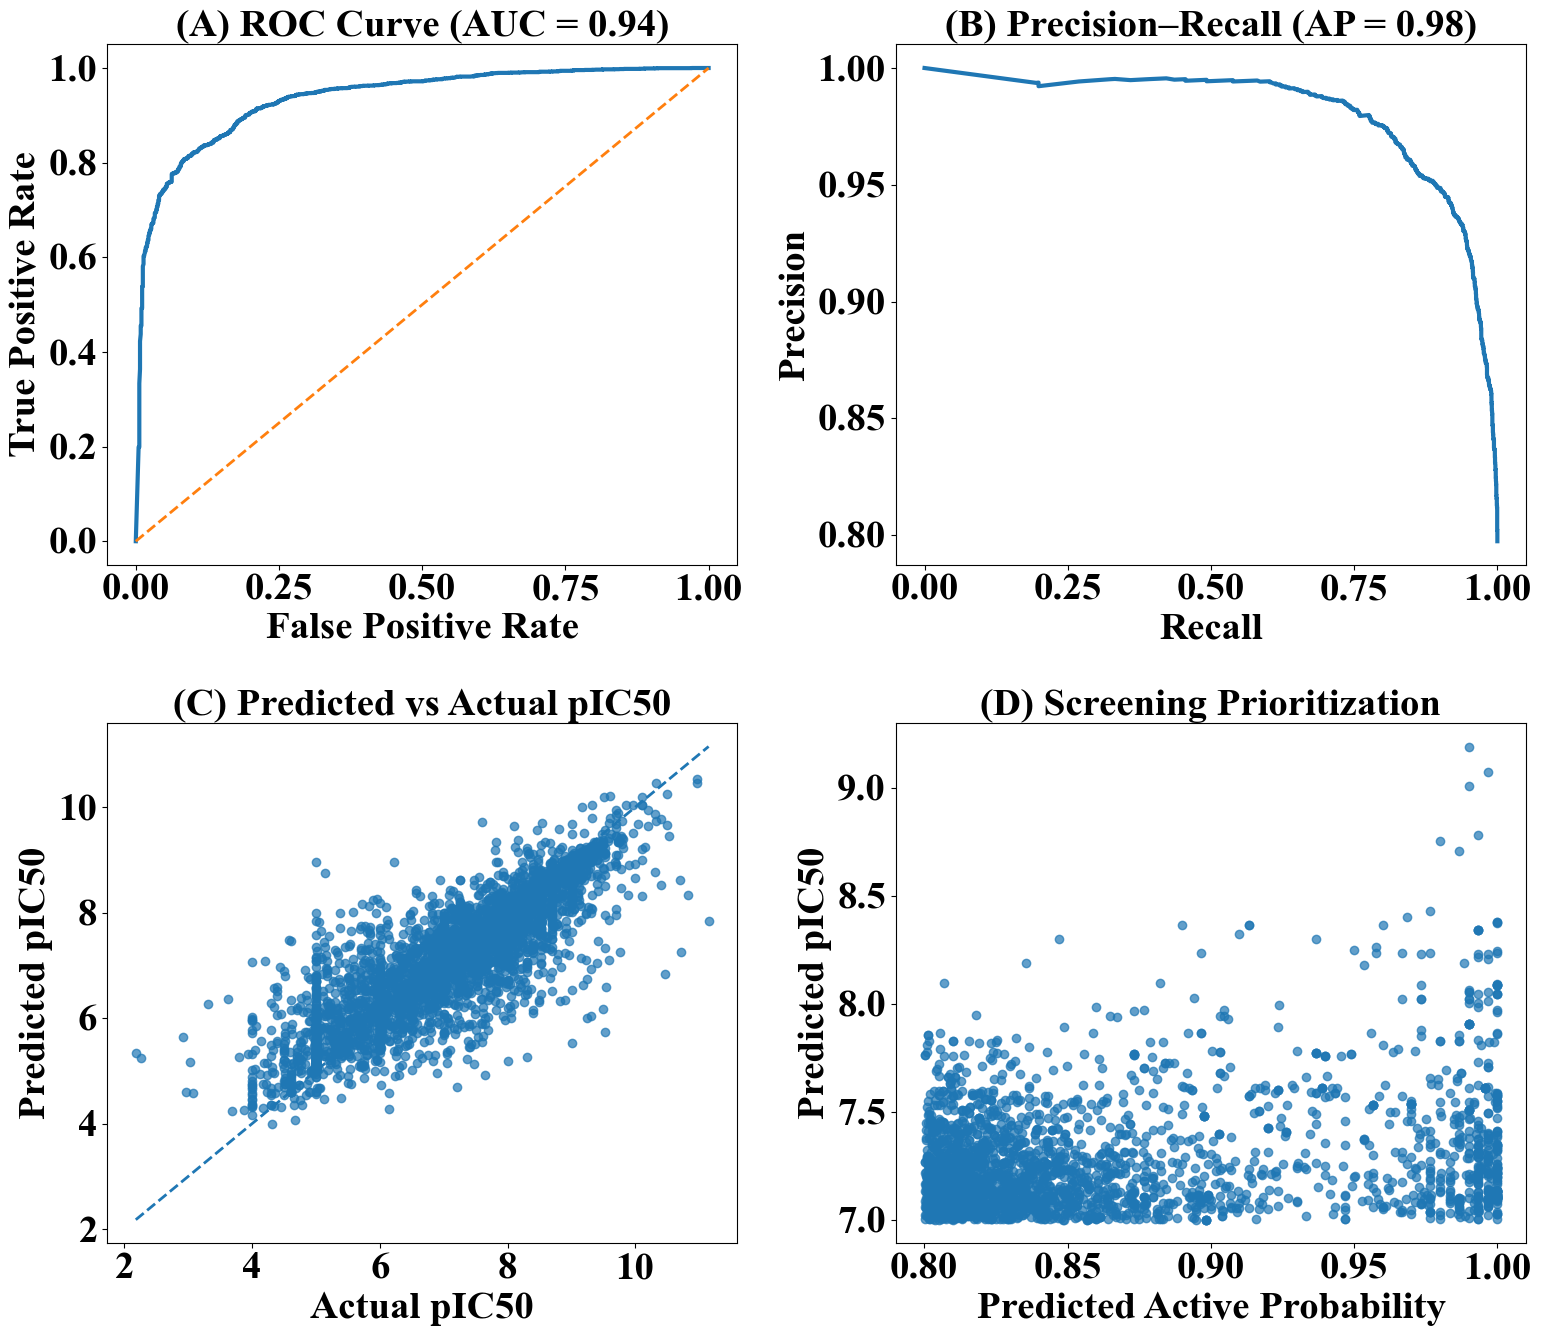

In [42]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# ============================================
# GLOBAL FONT SETTINGS (Times New Roman, Bold)
# ============================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 28
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"


# ============================================
# Load Best Saved Models
# ============================================

clf = joblib.load("RandomForest_Classifier.pkl")
reg = joblib.load("RandomForest_Regressor.pkl")

print("✅ Models loaded for figure generation")

# ============================================
# External Test Predictions
# ============================================

y_prob = clf.predict_proba(X_test)[:, 1]
yR_pred = reg.predict(X_test)

# ============================================
# Load Screening Hits File (Panel D)
# ============================================

screen_df = pd.read_csv("Top_ML_Hits.csv")

print("Screening hits loaded:", screen_df.shape)

# ============================================
# Create 2×2 Panel Figure
# ============================================

plt.figure(figsize=(16, 14))

# ----------------------------
# Panel A: ROC Curve
# ----------------------------
plt.subplot(2, 2, 1)

fpr, tpr, _ = roc_curve(yC_test, y_prob)
auc = roc_auc_score(yC_test, y_prob)

plt.plot(fpr, tpr, linewidth=3)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

plt.title(f"(A) ROC Curve (AUC = {auc:.2f})", fontsize=28, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=28, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=28, fontweight="bold")


# ----------------------------
# Panel B: Precision–Recall Curve
# ----------------------------
plt.subplot(2, 2, 2)

prec, rec, _ = precision_recall_curve(yC_test, y_prob)
ap = average_precision_score(yC_test, y_prob)

plt.plot(rec, prec, linewidth=3)

plt.title(f"(B) Precision–Recall (AP = {ap:.2f})", fontsize=28, fontweight="bold")
plt.xlabel("Recall", fontsize=28, fontweight="bold")
plt.ylabel("Precision", fontsize=28, fontweight="bold")


# ----------------------------
# Panel C: Predicted vs Actual pIC50
# ----------------------------
plt.subplot(2, 2, 3)

plt.scatter(yR_test, yR_pred, alpha=0.7)

min_val = min(yR_test.min(), yR_pred.min())
max_val = max(yR_test.max(), yR_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", linewidth=2)

plt.title("(C) Predicted vs Actual pIC50", fontsize=28, fontweight="bold")
plt.xlabel("Actual pIC50", fontsize=28, fontweight="bold")
plt.ylabel("Predicted pIC50", fontsize=28, fontweight="bold")


# ----------------------------
# Panel D: Screening Prioritization Scatter
# ----------------------------
plt.subplot(2, 2, 4)

plt.scatter(
    screen_df["Active_Prob"],
    screen_df["Pred_pIC50"],
    alpha=0.7
)

plt.title("(D) Screening Prioritization", fontsize=28, fontweight="bold")
plt.xlabel("Predicted Active Probability", fontsize=28, fontweight="bold")
plt.ylabel("Predicted pIC50", fontsize=28, fontweight="bold")


# ============================================
# Final Save (High Resolution)
# ============================================

plt.tight_layout()
plt.savefig("Figure_ML_2x2_TimesNewRoman.png", dpi=600)

print("\n✅ Final figure saved as: Figure_ML_2x2_TimesNewRoman.png")

✅ Saved: SI_PR_All_Classifiers.png


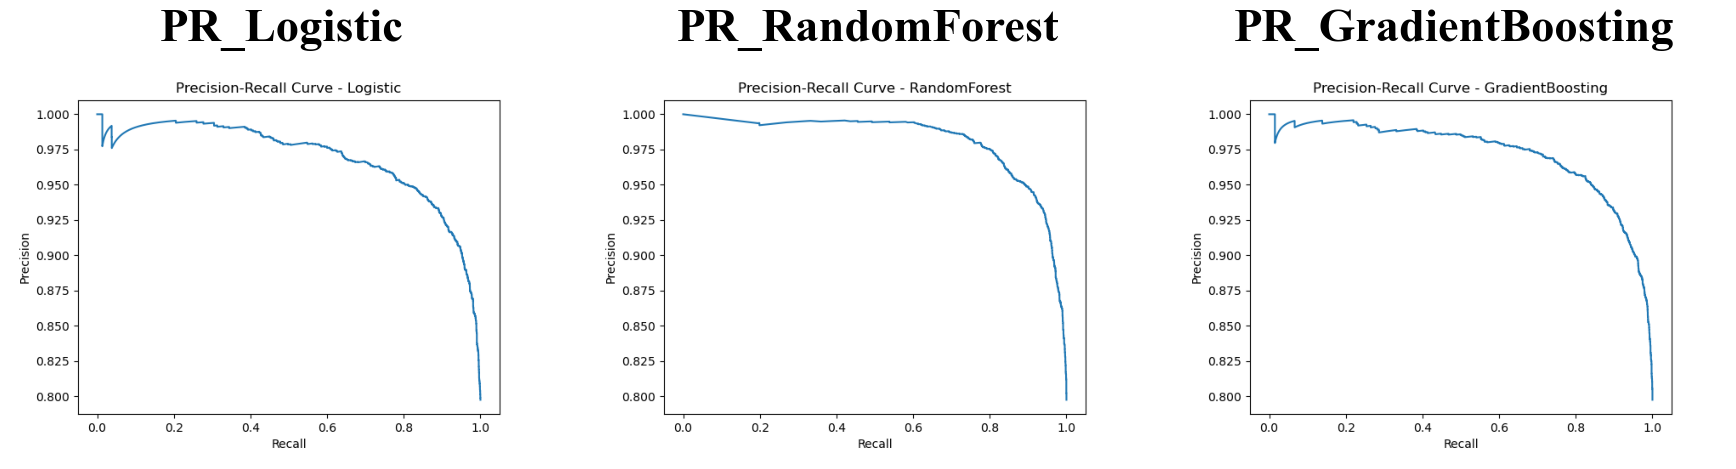

In [44]:
pr_files = [
    "PR_Logistic.png",
    "PR_RandomForest.png",
    "PR_GradientBoosting.png"
]

plt.figure(figsize=(18,6))

for i, file in enumerate(pr_files):
    img = Image.open(file)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(file.replace(".png",""))

plt.tight_layout()
plt.savefig("SI_PR_All_Classifiers.png", dpi=600)

print("✅ Saved: SI_PR_All_Classifiers.png")

✅ Best models loaded

✅ Final 2×2 performance panel saved as:
   Figure_Performance_2x2.png


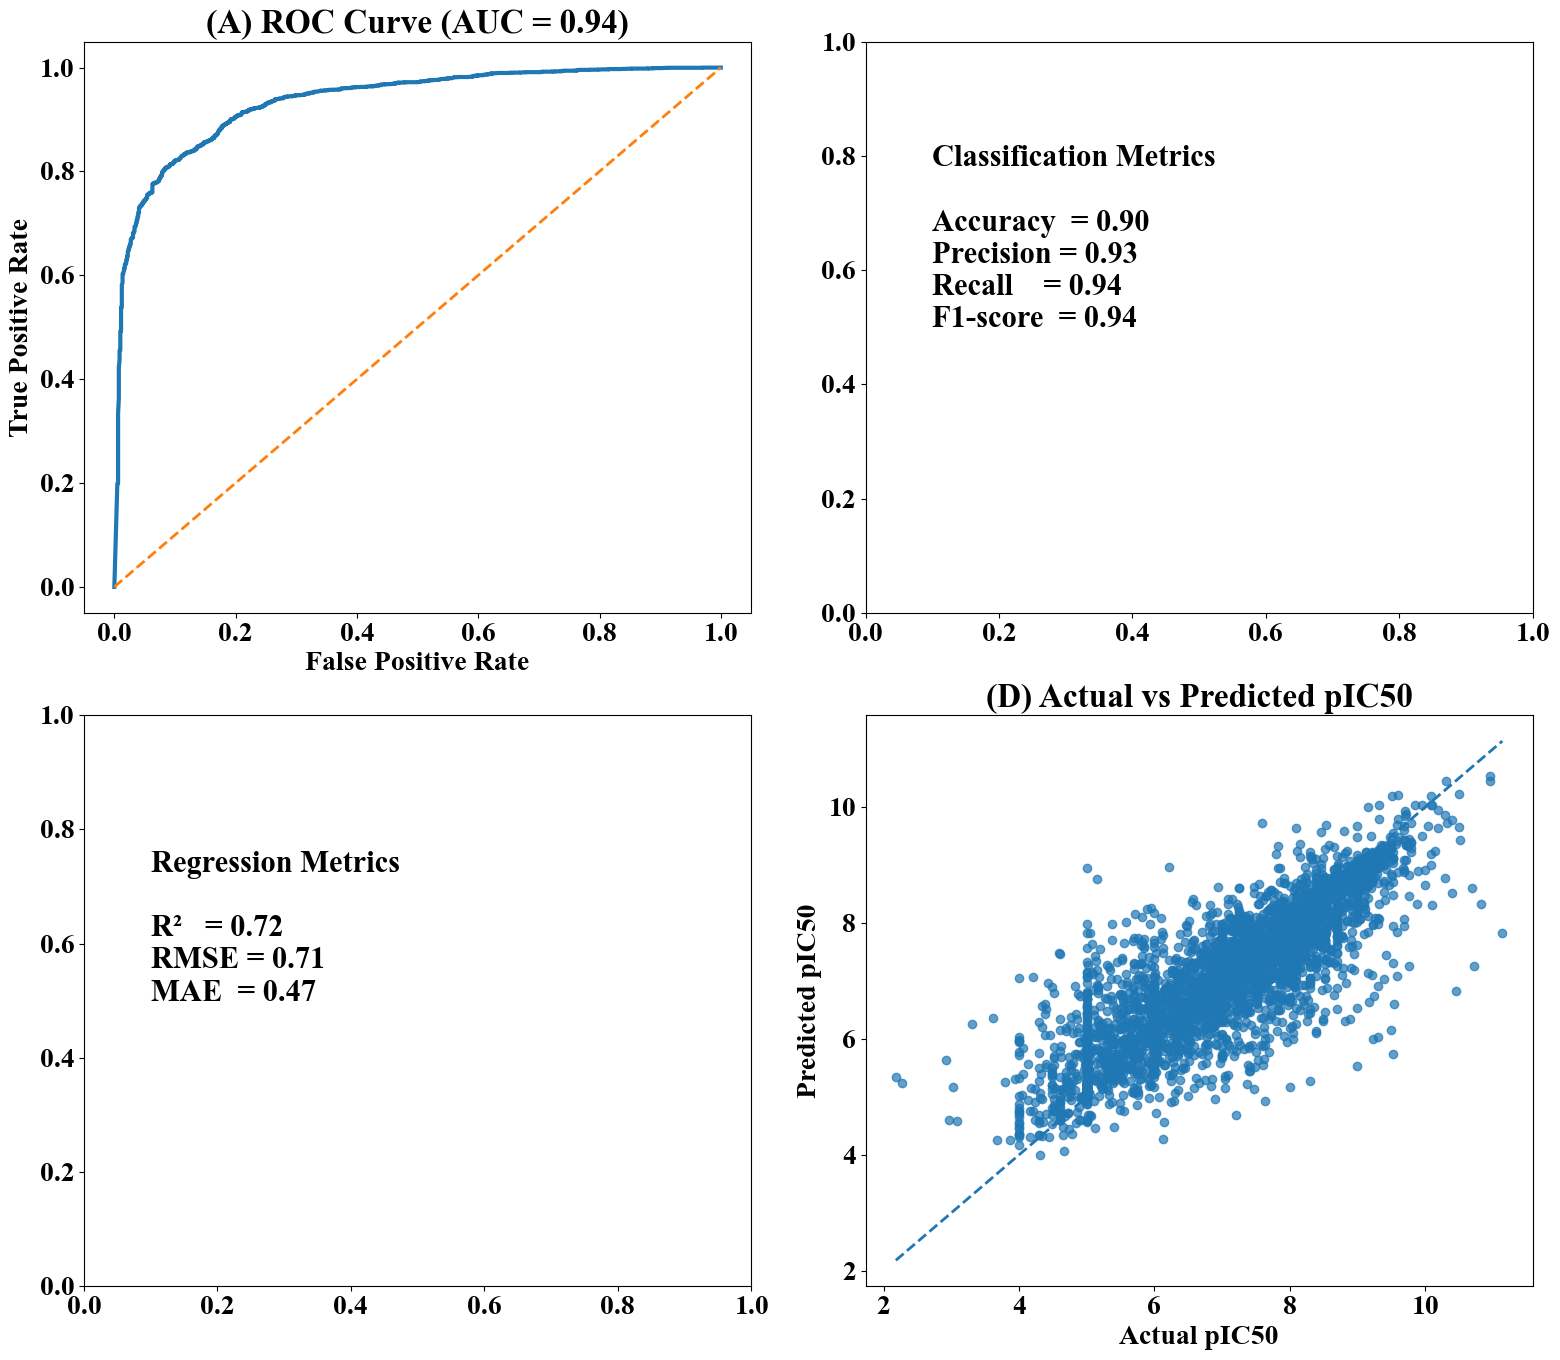

In [47]:
import matplotlib.pyplot as plt
import joblib
import numpy as np

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_squared_error, mean_absolute_error
)

# ==========================================================
# GLOBAL FONT SETTINGS
# ==========================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==========================================================
# Load Best Models
# ==========================================================

clf = joblib.load("RandomForest_Classifier.pkl")
reg = joblib.load("RandomForest_Regressor.pkl")

print("✅ Best models loaded")

# ==========================================================
# External Test Predictions
# ==========================================================

# Classifier probabilities + labels
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred_class = clf.predict(X_test)

# Regression prediction
y_pred_reg = reg.predict(X_test)

# ==========================================================
# Compute Metrics
# ==========================================================

# ---- Classification Metrics ----
acc = accuracy_score(yC_test, y_pred_class)
prec = precision_score(yC_test, y_pred_class)
rec = recall_score(yC_test, y_pred_class)
f1 = f1_score(yC_test, y_pred_class)

# ---- Regression Metrics ----
r2 = r2_score(yR_test, y_pred_reg)
rmse = mean_squared_error(yR_test, y_pred_reg) ** 0.5
mae = mean_absolute_error(yR_test, y_pred_reg)

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(yC_test, y_prob)
auc = roc_auc_score(yC_test, y_prob)

# ==========================================================
# Create 2×2 Panel Figure
# ==========================================================

plt.figure(figsize=(16, 14))

# ----------------------------------------------------------
# Panel A: ROC Curve
# ----------------------------------------------------------
plt.subplot(2, 2, 1)

plt.plot(fpr, tpr, linewidth=3)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

plt.title(f"(A) ROC Curve (AUC = {auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


# ----------------------------------------------------------
# Panel B: Classification Metrics Table
# ----------------------------------------------------------
plt.subplot(2, 2, 2)
plt.axis("on")

class_text = (
    f"Classification Metrics\n\n"
    f"Accuracy  = {acc:.2f}\n"
    f"Precision = {prec:.2f}\n"
    f"Recall    = {rec:.2f}\n"
    f"F1-score  = {f1:.2f}"
)

plt.text(0.1, 0.5, class_text, fontsize=22, fontweight="bold")


# ----------------------------------------------------------
# Panel C: Regression Metrics Table
# ----------------------------------------------------------
plt.subplot(2, 2, 3)
plt.axis("on")

reg_text = (
    f"Regression Metrics\n\n"
    f"R²   = {r2:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"MAE  = {mae:.2f}"
)

plt.text(0.1, 0.5, reg_text, fontsize=22, fontweight="bold")


# ----------------------------------------------------------
# Panel D: Experimental vs Predicted Scatter
# ----------------------------------------------------------
plt.subplot(2, 2, 4)

plt.scatter(yR_test, y_pred_reg, alpha=0.7)

# Diagonal reference line
min_val = min(yR_test.min(), y_pred_reg.min())
max_val = max(yR_test.max(), y_pred_reg.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", linewidth=2)

plt.title("(D) Actual vs Predicted pIC50")
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")


# ==========================================================
# Save Final Figure
# ==========================================================

plt.tight_layout()
plt.savefig("Figure_Performance_2x2.png", dpi=600)

print("\n✅ Final 2×2 performance panel saved as:")
print("   Figure_Performance_2x2.png")

✅ Models loaded

✅ Saved: Figure_Performance_2x2_Plots.png


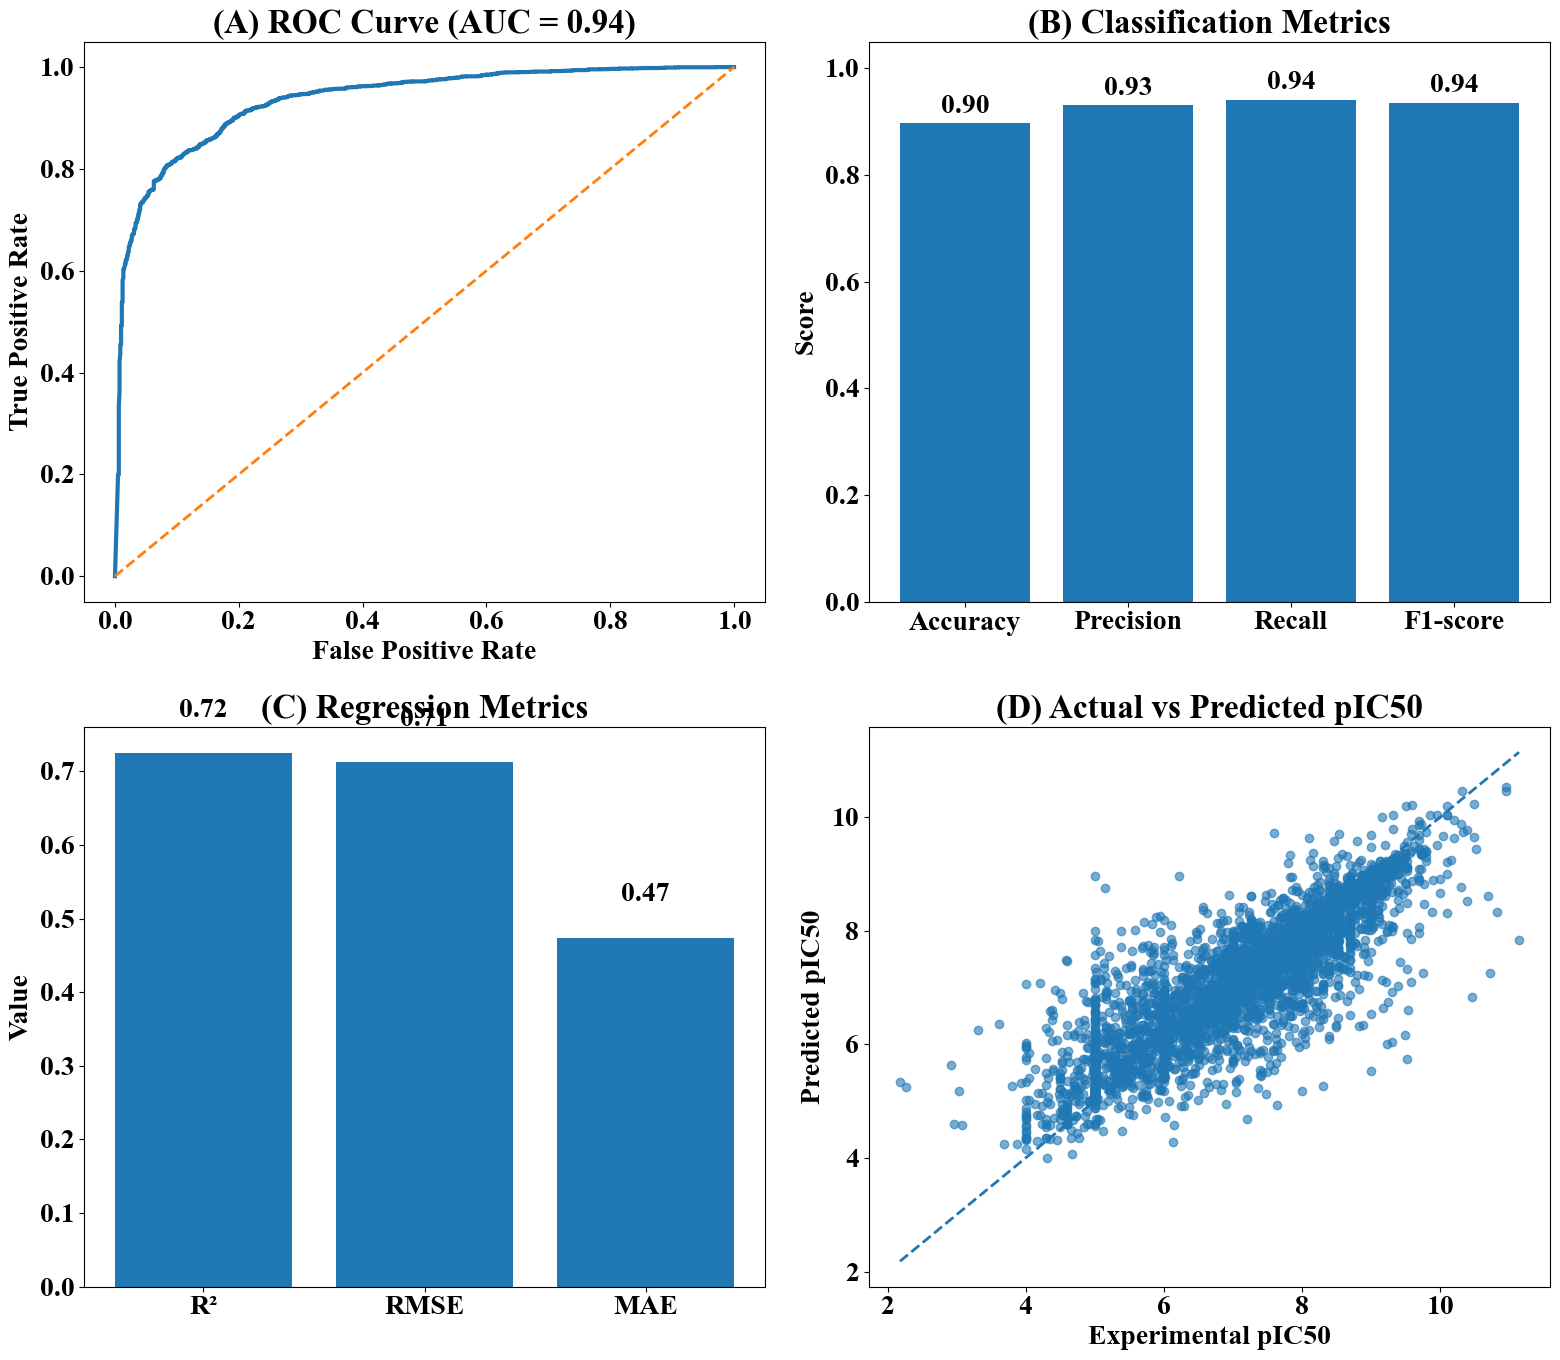

In [48]:
import matplotlib.pyplot as plt
import joblib
import numpy as np

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_squared_error, mean_absolute_error
)

# ==========================================================
# GLOBAL FONT SETTINGS
# ==========================================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==========================================================
# Load Best Models
# ==========================================================
clf = joblib.load("RandomForest_Classifier.pkl")
reg = joblib.load("RandomForest_Regressor.pkl")

print("✅ Models loaded")

# ==========================================================
# External Test Predictions
# ==========================================================
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred_class = clf.predict(X_test)

y_pred_reg = reg.predict(X_test)

# ==========================================================
# Compute Metrics
# ==========================================================

# Classification
acc = accuracy_score(yC_test, y_pred_class)
prec = precision_score(yC_test, y_pred_class)
rec = recall_score(yC_test, y_pred_class)
f1 = f1_score(yC_test, y_pred_class)

# Regression
r2 = r2_score(yR_test, y_pred_reg)
rmse = mean_squared_error(yR_test, y_pred_reg) ** 0.5
mae = mean_absolute_error(yR_test, y_pred_reg)

# ROC
fpr, tpr, _ = roc_curve(yC_test, y_prob)
auc = roc_auc_score(yC_test, y_prob)

# ==========================================================
# Create 2×2 Panel Figure
# ==========================================================
plt.figure(figsize=(16, 14))

# ----------------------------------------------------------
# Panel A: ROC Curve
# ----------------------------------------------------------
plt.subplot(2, 2, 1)

plt.plot(fpr, tpr, linewidth=3)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

plt.title(f"(A) ROC Curve (AUC = {auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# ----------------------------------------------------------
# Panel B: Classification Metrics Bar Plot
# ----------------------------------------------------------
plt.subplot(2, 2, 2)

class_names = ["Accuracy", "Precision", "Recall", "F1-score"]
class_values = [acc, prec, rec, f1]

plt.bar(class_names, class_values)

plt.ylim(0, 1.05)
plt.title("(B) Classification Metrics")
plt.ylabel("Score")

# Add values on bars
for i, v in enumerate(class_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

# ----------------------------------------------------------
# Panel C: Regression Metrics Bar Plot
# ----------------------------------------------------------
plt.subplot(2, 2, 3)

reg_names = ["R²", "RMSE", "MAE"]
reg_values = [r2, rmse, mae]

plt.bar(reg_names, reg_values)

plt.title("(C) Regression Metrics")
plt.ylabel("Value")

# Add values on bars
for i, v in enumerate(reg_values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

# ----------------------------------------------------------
# Panel D: Experimental vs Predicted Scatter
# ----------------------------------------------------------
plt.subplot(2, 2, 4)

plt.scatter(yR_test, y_pred_reg, alpha=0.6)

# Diagonal line
min_val = min(yR_test.min(), y_pred_reg.min())
max_val = max(yR_test.max(), y_pred_reg.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", linewidth=2)

plt.title("(D) Actual vs Predicted pIC50")
plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")

# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()
plt.savefig("Figure_Performance_2x2_Plots.png", dpi=600)

print("\n✅ Saved: Figure_Performance_2x2_Plots.png")

✅ Models loaded successfully


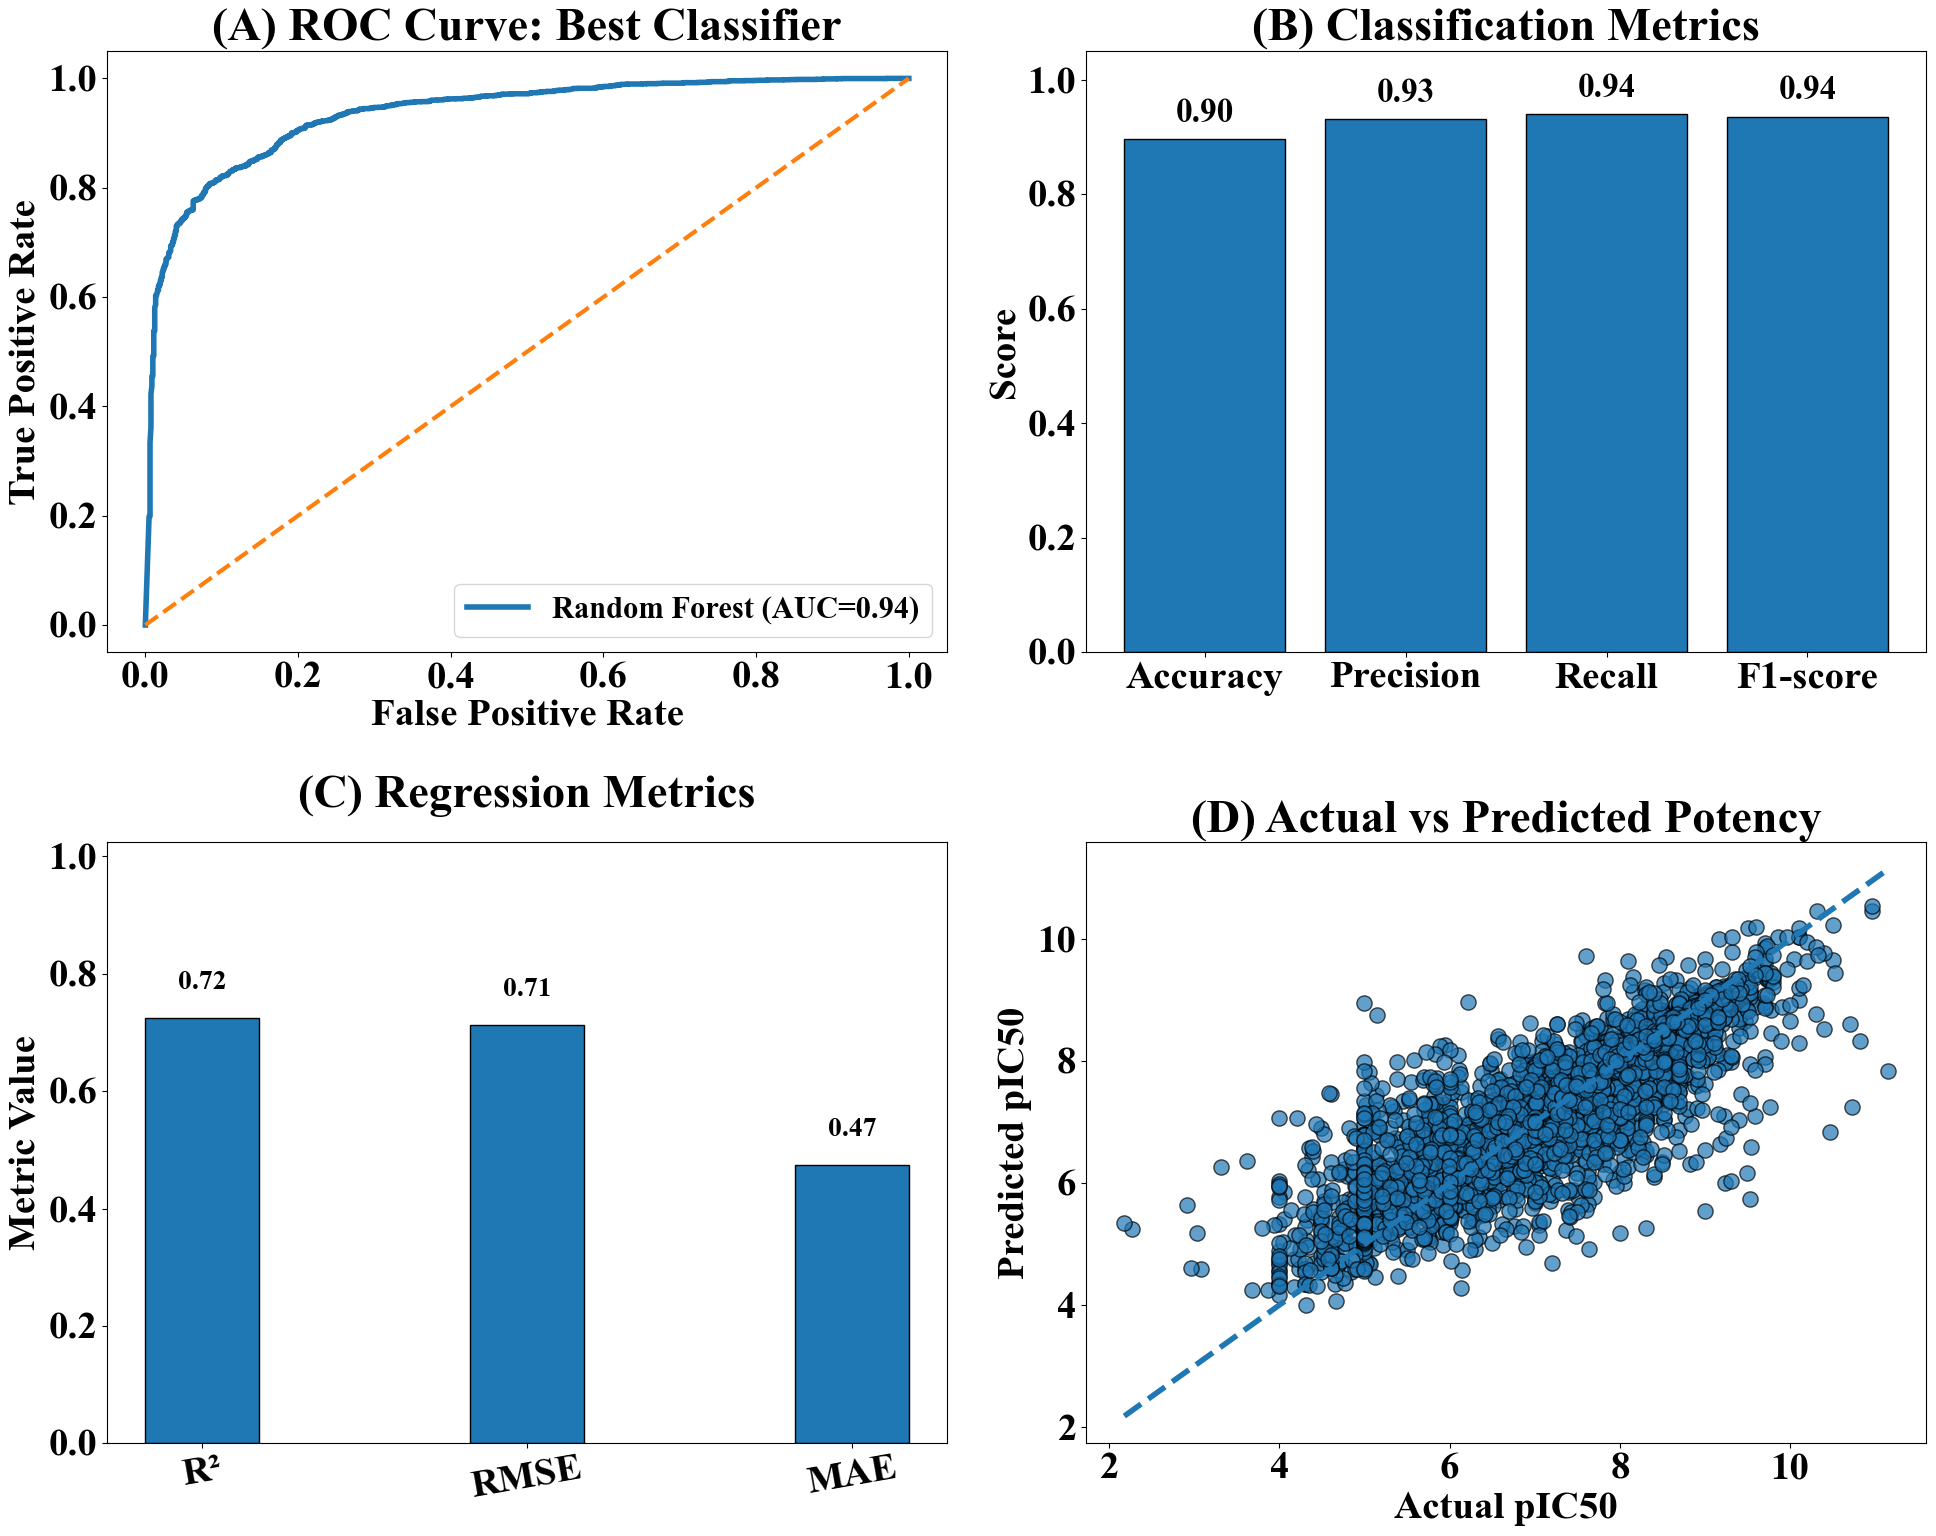

✅ Combined ATS Panel Saved: ATS_Combined_QSAR_2x2_Panel.png


In [54]:
# ==========================================================
# ATS Combined 2×2 Panel Figure (Direct Pipeline Version)
# (A) ROC Curve (Best Classifier)
# (B) Classification Metrics Bar Plot
# (C) Regression Metrics Bar Plot
# (D) Experimental vs Predicted Scatter
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_squared_error, mean_absolute_error
)

# ==========================================================
# GLOBAL STYLE (ATS Journal)
# ==========================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 28
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==========================================================
# Load Best Saved Models (from your pipeline)
# ==========================================================

clf = joblib.load("RandomForest_Classifier.pkl")
reg = joblib.load("RandomForest_Regressor.pkl")

print("✅ Models loaded successfully")

# ==========================================================
# External Test Predictions
# ==========================================================

# Classification predictions
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred_class = clf.predict(X_test)

# Regression predictions
y_pred_reg = reg.predict(X_test)

# ==========================================================
# Compute Classification Metrics
# ==========================================================

acc = accuracy_score(yC_test, y_pred_class)
prec = precision_score(yC_test, y_pred_class)
rec = recall_score(yC_test, y_pred_class)
f1 = f1_score(yC_test, y_pred_class)

# ==========================================================
# Compute Regression Metrics
# ==========================================================

r2 = r2_score(yR_test, y_pred_reg)
rmse = mean_squared_error(yR_test, y_pred_reg) ** 0.5
mae = mean_absolute_error(yR_test, y_pred_reg)

# ==========================================================
# ROC Curve Data
# ==========================================================

fpr, tpr, _ = roc_curve(yC_test, y_prob)
roc_auc = auc(fpr, tpr)

# ==========================================================
# Create 2×2 Figure Layout
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# ==========================================================
# PANEL A: ROC CURVE
# ==========================================================

ax = axes[0, 0]

ax.plot(fpr, tpr, linewidth=4,
        label=f"Random Forest (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], "--", linewidth=3)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(A) ROC Curve: Best Classifier")
ax.legend(fontsize=22)

# ==========================================================
# PANEL B: Classification Metrics Bar Plot
# ==========================================================

ax = axes[0, 1]

cls_names = ["Accuracy", "Precision", "Recall", "F1-score"]
cls_values = [acc, prec, rec, f1]

ax.bar(cls_names, cls_values, edgecolor="black")

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("(B) Classification Metrics")

for i, v in enumerate(cls_values):
    ax.text(i, v + 0.03, f"{v:.2f}",
            ha="center", fontsize=24, fontweight="bold")

# ==========================================================
# ==========================================================
# ==========================================================
# PANEL C: Regression Metrics Bar Plot (Fixed)
# ==========================================================

ax = axes[1, 0]

reg_names = ["R²", "RMSE", "MAE"]
reg_values = [r2, rmse, mae]

bars = ax.bar(
    reg_names,
    reg_values,
    width=0.35,
    edgecolor="black"
)

# Add extra space above bars
ax.set_ylim(0, max(reg_values) + 0.30)

ax.set_ylabel("Metric Value")
ax.set_title("(C) Regression Metrics", pad=25)

# Add values safely above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        fontsize=20,
        fontweight="bold"
    )

# Slight x-label rotation
ax.tick_params(axis="x", rotation=10)
# ==========================================================
# PANEL D: Experimental vs Predicted Scatter
# ==========================================================

ax = axes[1, 1]

ax.scatter(
    yR_test, y_pred_reg,
    s=120,
    edgecolor="black",
    alpha=0.7
)

ax.set_xlabel("Actual pIC50")
ax.set_ylabel("Predicted pIC50")
ax.set_title("(D) Actual vs Predicted Potency")

# Perfect diagonal line
min_val = min(yR_test.min(), y_pred_reg.min())
max_val = max(yR_test.max(), y_pred_reg.max())
ax.plot([min_val, max_val], [min_val, max_val],
        "--", linewidth=4)

# ==========================================================
# FINAL SAVE
# ==========================================================

plt.tight_layout()

plt.savefig("ATS_Combined_QSAR_2x2_Panel.png",
            dpi=600,
            bbox_inches="tight")

plt.show()

print("✅ Combined ATS Panel Saved: ATS_Combined_QSAR_2x2_Panel.png")

✅ Saved: SI_Combined_ROC.png


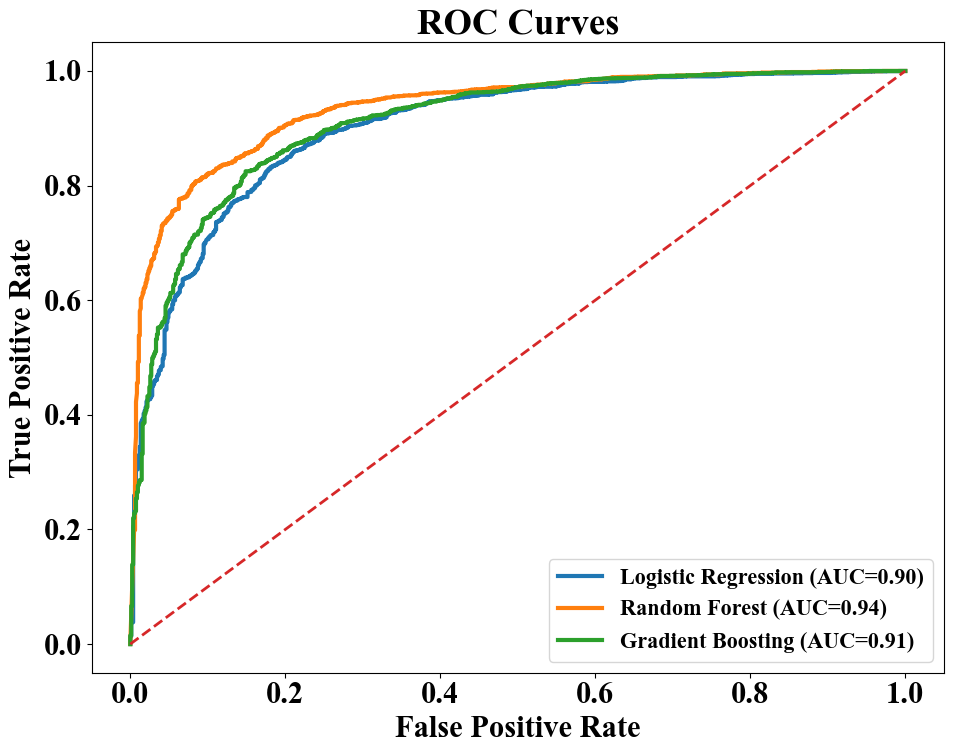

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import joblib

# ================================
# Global Style (SI Journal)
# ================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 22
plt.rcParams["font.weight"] = "bold"

# ================================
# Load Saved Classifiers
# ================================
models = {
    "Logistic Regression": joblib.load("Logistic_Classifier.pkl"),
    "Random Forest": joblib.load("RandomForest_Classifier.pkl"),
    "Gradient Boosting": joblib.load("GradientBoosting_Classifier.pkl")
}

# ================================
# Plot ROC Curves Together
# ================================
plt.figure(figsize=(10, 8))

for name, clf in models.items():

    # Predict probability
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(yC_test, y_prob)

    # AUC
    auc = roc_auc_score(yC_test, y_prob)

    plt.plot(fpr, tpr, linewidth=3,
             label=f"{name} (AUC={auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], "--", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend(loc="lower right", fontsize=16)

plt.tight_layout()
plt.savefig("SI_Combined_ROC.png", dpi=600)

print("✅ Saved: SI_Combined_ROC.png")

✅ Saved: SI_Combined_PR.png


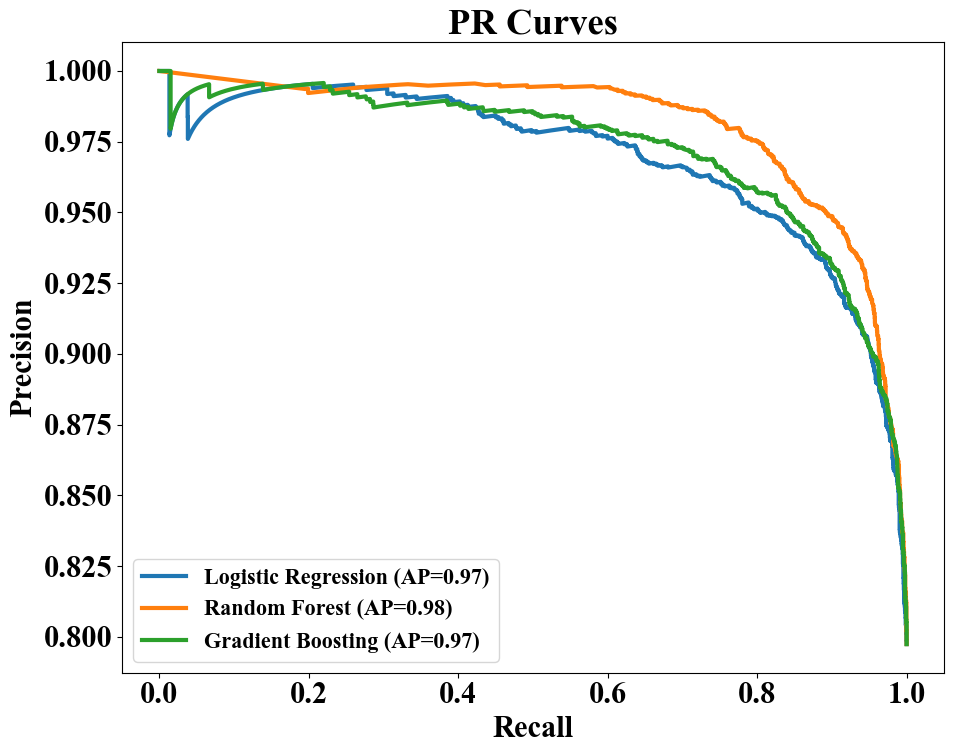

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import joblib

# ================================
# Global Style
# ================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 22
plt.rcParams["font.weight"] = "bold"

# ================================
# Load Saved Classifiers
# ================================
models = {
    "Logistic Regression": joblib.load("Logistic_Classifier.pkl"),
    "Random Forest": joblib.load("RandomForest_Classifier.pkl"),
    "Gradient Boosting": joblib.load("GradientBoosting_Classifier.pkl")
}

# ================================
# Plot PR Curves Together
# ================================
plt.figure(figsize=(10, 8))

for name, clf in models.items():

    # Predict probability
    y_prob = clf.predict_proba(X_test)[:, 1]

    # PR curve
    prec, rec, _ = precision_recall_curve(yC_test, y_prob)

    # Average Precision Score
    ap = average_precision_score(yC_test, y_prob)

    plt.plot(rec, prec, linewidth=3,
             label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves")

plt.legend(loc="lower left", fontsize=16)

plt.tight_layout()
plt.savefig("SI_Combined_PR.png", dpi=600)

print("✅ Saved: SI_Combined_PR.png")

✅ Saved: SI_Combined_RegScatter.png


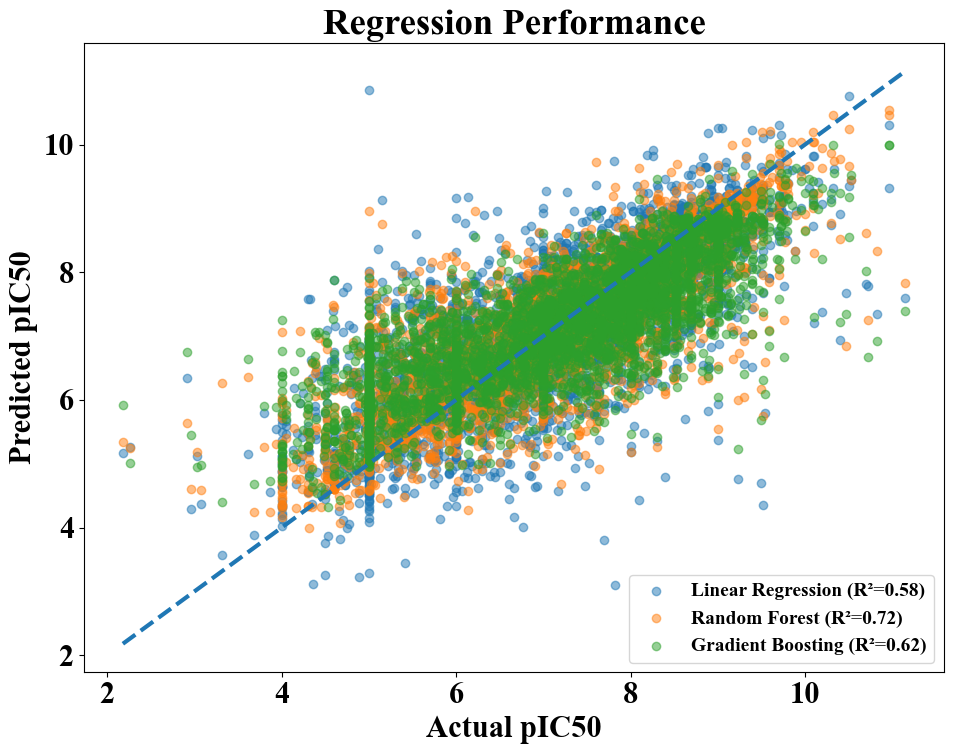

In [61]:
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import r2_score

# ================================
# Global Style (SI Journal)
# ================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 22
plt.rcParams["font.weight"] = "bold"

# ================================
# Load Saved Regressors
# ================================
models = {
    "Linear Regression": joblib.load("Linear_Regressor.pkl"),
    "Random Forest": joblib.load("RandomForest_Regressor.pkl"),
    "Gradient Boosting": joblib.load("GradientBoosting_Regressor.pkl")
}

# ================================
# Create Combined Scatter Plot
# ================================
plt.figure(figsize=(10, 8))

for name, reg in models.items():

    # Predict pIC50
    y_pred = reg.predict(X_test)

    # Compute R²
    r2 = r2_score(yR_test, y_pred)

    # Scatter plot
    plt.scatter(
        yR_test, y_pred,
        alpha=0.5,
        label=f"{name} (R²={r2:.2f})"
    )

# Perfect diagonal
min_val = min(yR_test.min(), yR_test.min())
max_val = max(yR_test.max(), yR_test.max())

plt.plot([min_val, max_val], [min_val, max_val],
         "--", linewidth=3)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Regression Performance")

plt.legend(fontsize=14)
plt.tight_layout()

plt.savefig("SI_Combined_RegScatter.png", dpi=600)

print("✅ Saved: SI_Combined_RegScatter.png")

✅ Saved: SI_Combined_Residuals.png


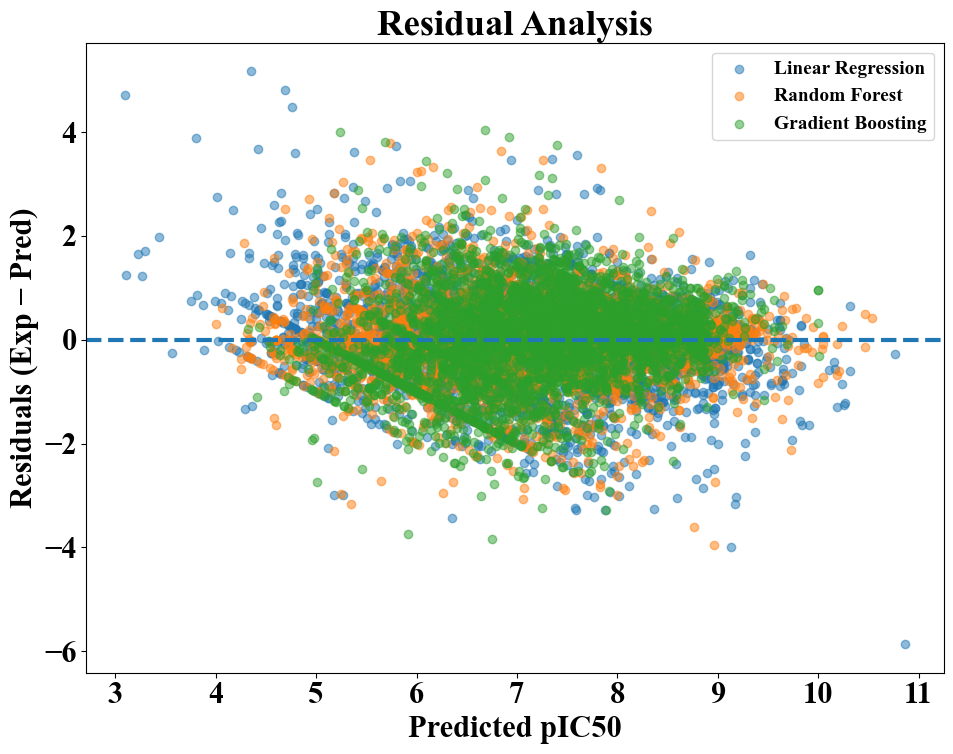

In [62]:
import matplotlib.pyplot as plt
import joblib

# ================================
# Global Style
# ================================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 22
plt.rcParams["font.weight"] = "bold"

# ================================
# Load Saved Regressors
# ================================
models = {
    "Linear Regression": joblib.load("Linear_Regressor.pkl"),
    "Random Forest": joblib.load("RandomForest_Regressor.pkl"),
    "Gradient Boosting": joblib.load("GradientBoosting_Regressor.pkl")
}

# ================================
# Create Residual Plot
# ================================
plt.figure(figsize=(10, 8))

for name, reg in models.items():

    # Predict
    y_pred = reg.predict(X_test)

    # Residuals
    residuals = yR_test - y_pred

    # Scatter residuals
    plt.scatter(
        y_pred, residuals,
        alpha=0.5,
        label=name
    )

# Horizontal zero line
plt.axhline(0, linestyle="--", linewidth=3)

plt.xlabel("Predicted pIC50")
plt.ylabel("Residuals (Exp − Pred)")
plt.title("Residual Analysis")

plt.legend(fontsize=14)
plt.tight_layout()

plt.savefig("SI_Combined_Residuals.png", dpi=600)

print("✅ Saved: SI_Combined_Residuals.png")